# Vehicle Damage Assessment System - Feature Engineering

**Project:** Smart Repair Locator - Garage Recommendation System


**Objective:** Create powerful features from cleaned data to train ML models for garage recommendations

---

## Table of Contents
1. [Setup & Load Cleaned Data](#section1)
2. [Distance-Based Features](#section2)
3. [Specialization Matching Features](#section3)
4. [Historical Performance Features](#section4)
5. [User Preference Features](#section5)
6. [Availability & Capacity Features](#section6)
7. [Price & Cost Features](#section7)
8. [Create Training Dataset](#section8)
9. [Feature Analysis](#section9)
10. [Save Engineered Features](#section10)

---
<a id='section1'></a>
## 1. Setup & Load Cleaned Data

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from math import radians, cos, sin, asin, sqrt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")
print(f"📅 Feature Engineering Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries imported successfully!
📅 Feature Engineering Date: 2025-11-19 14:12:59


In [2]:
# Load cleaned datasets
DATA_PATH = 'data/processed/'

print("📂 Loading cleaned datasets...\n")

garages_df = pd.read_csv(DATA_PATH + 'garages_clean.csv')
print(f"✓ Garages: {garages_df.shape}")

repairs_df = pd.read_csv(DATA_PATH + 'repairs_clean.csv')
print(f"✓ Repairs: {repairs_df.shape}")

users_df = pd.read_csv(DATA_PATH + 'users_clean.csv')
print(f"✓ Users: {users_df.shape}")

damage_ref_df = pd.read_csv(DATA_PATH + 'damage_reference_clean.csv')
print(f"✓ Damage Reference: {damage_ref_df.shape}")

specializations_df = pd.read_csv(DATA_PATH + 'specializations_clean.csv')
print(f"✓ Specializations: {specializations_df.shape}")

capacity_df = pd.read_csv(DATA_PATH + 'capacity_clean.csv')
print(f"✓ Capacity: {capacity_df.shape}")

print("\n✅ All datasets loaded successfully!")

📂 Loading cleaned datasets...

✓ Garages: (100, 17)
✓ Repairs: (1000, 20)
✓ Users: (400, 16)
✓ Damage Reference: (90, 15)
✓ Specializations: (294, 10)
✓ Capacity: (36500, 12)

✅ All datasets loaded successfully!


---
<a id='section2'></a>
## 2. Distance-Based Features

Calculate distances between user locations and garages using Haversine formula

In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points on Earth
    Returns distance in kilometers
    """
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    # Radius of Earth in kilometers
    r = 6371
    
    return c * r

print("✅ Distance calculation function defined!")

# Test the function
test_distance = haversine_distance(6.9271, 79.8612, 6.8561, 79.8642)
print(f"\n📏 Test: Distance between two Colombo points: {test_distance:.2f} km")

✅ Distance calculation function defined!

📏 Test: Distance between two Colombo points: 7.90 km


🧮 Calculating distance features for repairs dataset...

✅ Distance features created!

📊 Distance Statistics:
   Mean distance: 13.25 km
   Median distance: 13.91 km
   Min distance: 0.88 km
   Max distance: 20.03 km

📊 Distance Category Distribution:
distance_category
very_close     12
close          54
moderate      186
far           744
very_far        4
Name: count, dtype: int64


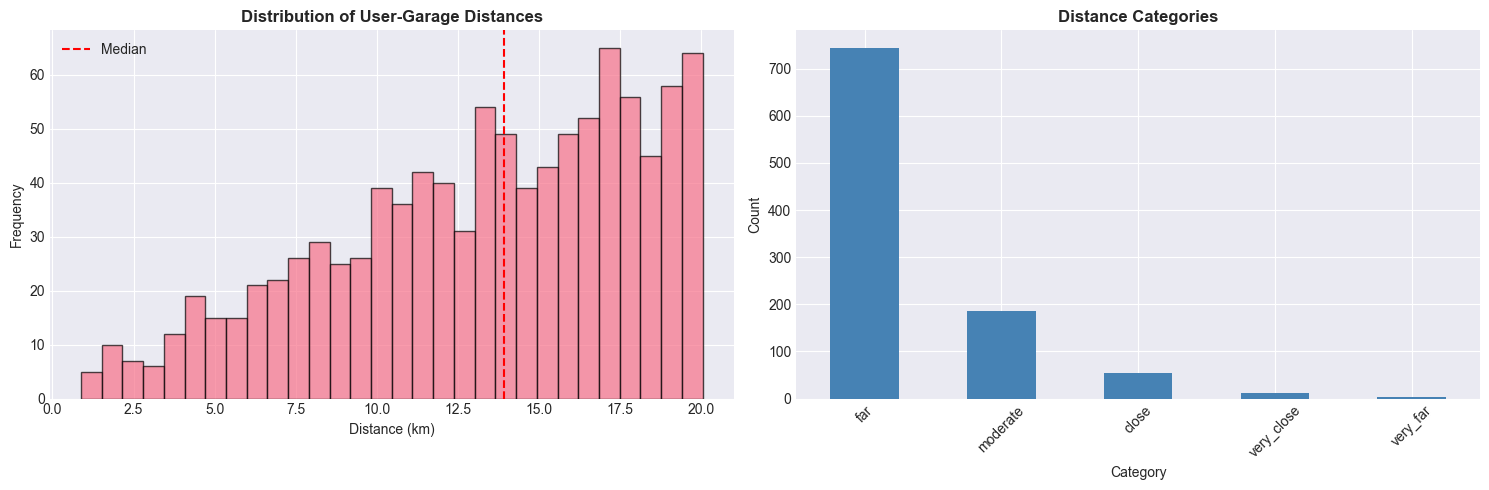

In [4]:
print("🧮 Calculating distance features for repairs dataset...\n")

# Add distance column if coordinates exist
if all(col in repairs_df.columns for col in ['user_location_lat', 'user_location_lon']) and \
   all(col in garages_df.columns for col in ['latitude', 'longitude']):
    
    # Merge garage coordinates into repairs
    repairs_with_coords = repairs_df.merge(
        garages_df[['garage_id', 'latitude', 'longitude']], 
        on='garage_id', 
        how='left'
    )
    
    # Calculate distance if not already present or recalculate
    repairs_with_coords['calculated_distance_km'] = repairs_with_coords.apply(
        lambda row: haversine_distance(
            row['user_location_lat'], 
            row['user_location_lon'],
            row['latitude'], 
            row['longitude']
        ), axis=1
    )
    
    # Create distance-based features
    repairs_with_coords['distance_score'] = 1 / (1 + repairs_with_coords['calculated_distance_km'])
    repairs_with_coords['is_nearby'] = (repairs_with_coords['calculated_distance_km'] <= 5).astype(int)
    repairs_with_coords['is_very_close'] = (repairs_with_coords['calculated_distance_km'] <= 2).astype(int)
    
    # Distance categories
    repairs_with_coords['distance_category'] = pd.cut(
        repairs_with_coords['calculated_distance_km'],
        bins=[0, 2, 5, 10, 20, 100],
        labels=['very_close', 'close', 'moderate', 'far', 'very_far']
    )
    
    print("✅ Distance features created!")
    print(f"\n📊 Distance Statistics:")
    print(f"   Mean distance: {repairs_with_coords['calculated_distance_km'].mean():.2f} km")
    print(f"   Median distance: {repairs_with_coords['calculated_distance_km'].median():.2f} km")
    print(f"   Min distance: {repairs_with_coords['calculated_distance_km'].min():.2f} km")
    print(f"   Max distance: {repairs_with_coords['calculated_distance_km'].max():.2f} km")
    
    print(f"\n📊 Distance Category Distribution:")
    print(repairs_with_coords['distance_category'].value_counts().sort_index())
    
    # Visualize distance distribution
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].hist(repairs_with_coords['calculated_distance_km'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of User-Garage Distances', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Distance (km)')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(repairs_with_coords['calculated_distance_km'].median(), 
                    color='red', linestyle='--', label='Median')
    axes[0].legend()
    
    repairs_with_coords['distance_category'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Distance Categories', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Category')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ Required coordinate columns not found")
    repairs_with_coords = repairs_df.copy()

---
<a id='section3'></a>
## 3. Specialization Matching Features

Create features that measure how well a garage's specialization matches the repair needs

In [5]:
print("🔧 Creating specialization matching features...\n")

# Create damage type to specialization mapping
damage_to_specialization = {
    'minor': ['body_work', 'paint_work'],
    'moderate': ['body_work', 'paint_work', 'general_repair'],
    'severe': ['body_work', 'structural_repair', 'general_repair']
}

# Create repair category mapping if available in damage reference
if 'damage_type' in damage_ref_df.columns and 'primary_repair_needed' in damage_ref_df.columns:
    damage_repair_map = damage_ref_df.set_index('damage_type')['primary_repair_needed'].to_dict()
    print(f"✓ Created damage-to-repair mapping from reference data")
else:
    damage_repair_map = {}
    print("⚠️ Using default damage-to-repair mapping")

# Function to calculate specialization match score
def calculate_specialization_match(damage_type, repair_category, garage_specializations):
    """
    Calculate how well garage specializations match the repair needs
    Returns a score between 0 and 1
    """
    if pd.isna(garage_specializations):
        return 0.5  # Neutral score if specializations unknown
    
    # Convert to lowercase and split
    garage_specs = str(garage_specializations).lower().split(',')
    garage_specs = [spec.strip() for spec in garage_specs]
    
    # Check if repair_category matches
    if repair_category and str(repair_category).lower() in garage_specs:
        return 1.0
    
    # Check damage type mapping
    required_specs = damage_to_specialization.get(str(damage_type).lower(), [])
    if any(spec in garage_specs for spec in required_specs):
        return 0.8
    
    # General repair shops get moderate score
    if 'general_repair' in garage_specs:
        return 0.6
    
    return 0.3  # Low match

print("✅ Specialization matching function defined!")

🔧 Creating specialization matching features...

✓ Created damage-to-repair mapping from reference data
✅ Specialization matching function defined!


✅ Specialization match scores calculated!

📊 Match Score Statistics:
   Mean: 0.632
   Median: 0.800

📊 Match Quality Distribution:
match_quality
excellent    543
poor         427
good          30
Name: count, dtype: int64


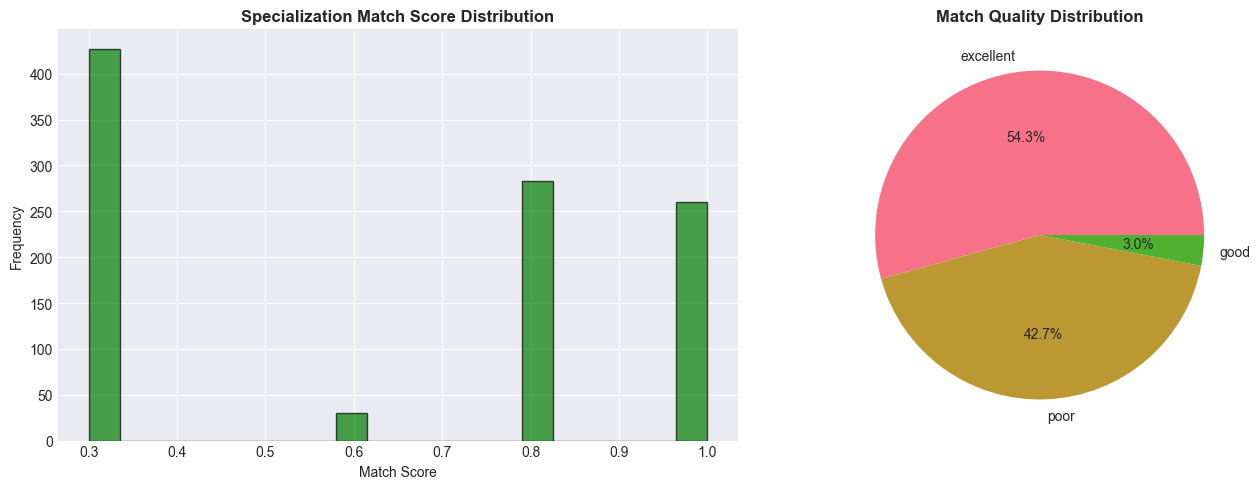

In [6]:
# Add specialization features to repairs
if 'garage_id' in repairs_with_coords.columns and 'specializations' in garages_df.columns:
    # Merge specializations
    repairs_with_coords = repairs_with_coords.merge(
        garages_df[['garage_id', 'specializations']],
        on='garage_id',
        how='left',
        suffixes=('', '_garage')
    )
    
    # Calculate specialization match score
    if 'damage_type' in repairs_with_coords.columns:
        repairs_with_coords['specialization_match_score'] = repairs_with_coords.apply(
            lambda row: calculate_specialization_match(
                row.get('damage_type', ''),
                row.get('repair_category', ''),
                row.get('specializations', '')
            ), axis=1
        )
        
        print("✅ Specialization match scores calculated!")
        print(f"\n📊 Match Score Statistics:")
        print(f"   Mean: {repairs_with_coords['specialization_match_score'].mean():.3f}")
        print(f"   Median: {repairs_with_coords['specialization_match_score'].median():.3f}")
        
        # Categorize matches
        repairs_with_coords['match_quality'] = pd.cut(
            repairs_with_coords['specialization_match_score'],
            bins=[0, 0.4, 0.7, 1.0],
            labels=['poor', 'good', 'excellent']
        )
        
        print(f"\n📊 Match Quality Distribution:")
        print(repairs_with_coords['match_quality'].value_counts())
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].hist(repairs_with_coords['specialization_match_score'], 
                     bins=20, edgecolor='black', alpha=0.7, color='green')
        axes[0].set_title('Specialization Match Score Distribution', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Match Score')
        axes[0].set_ylabel('Frequency')
        
        repairs_with_coords['match_quality'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
        axes[1].set_title('Match Quality Distribution', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('')
        
        plt.tight_layout()
        plt.show()

else:
    print("⚠️ Specializations data not available")

---
<a id='section4'></a>
## 4. Historical Performance Features

Aggregate historical performance metrics for each garage

📊 Creating historical performance features...

✅ Historical performance features created!

📊 Performance Summary:
  garage_id  historical_satisfaction_rate  total_repairs  avg_historical_cost   
0    GAR001                         0.882             17           181226.000  \
1    GAR002                         0.882             34           176045.118   
2    GAR003                         1.000              7           194022.714   
3    GAR004                         0.583             12            39494.583   
4    GAR005                         0.714             14            86636.929   
5    GAR006                         0.636             11           228740.727   
6    GAR007                         0.667             12            71147.917   
7    GAR008                         0.800             15           139390.533   
8    GAR009                         0.875              8           228538.250   
9    GAR010                         0.667              3            65646.33

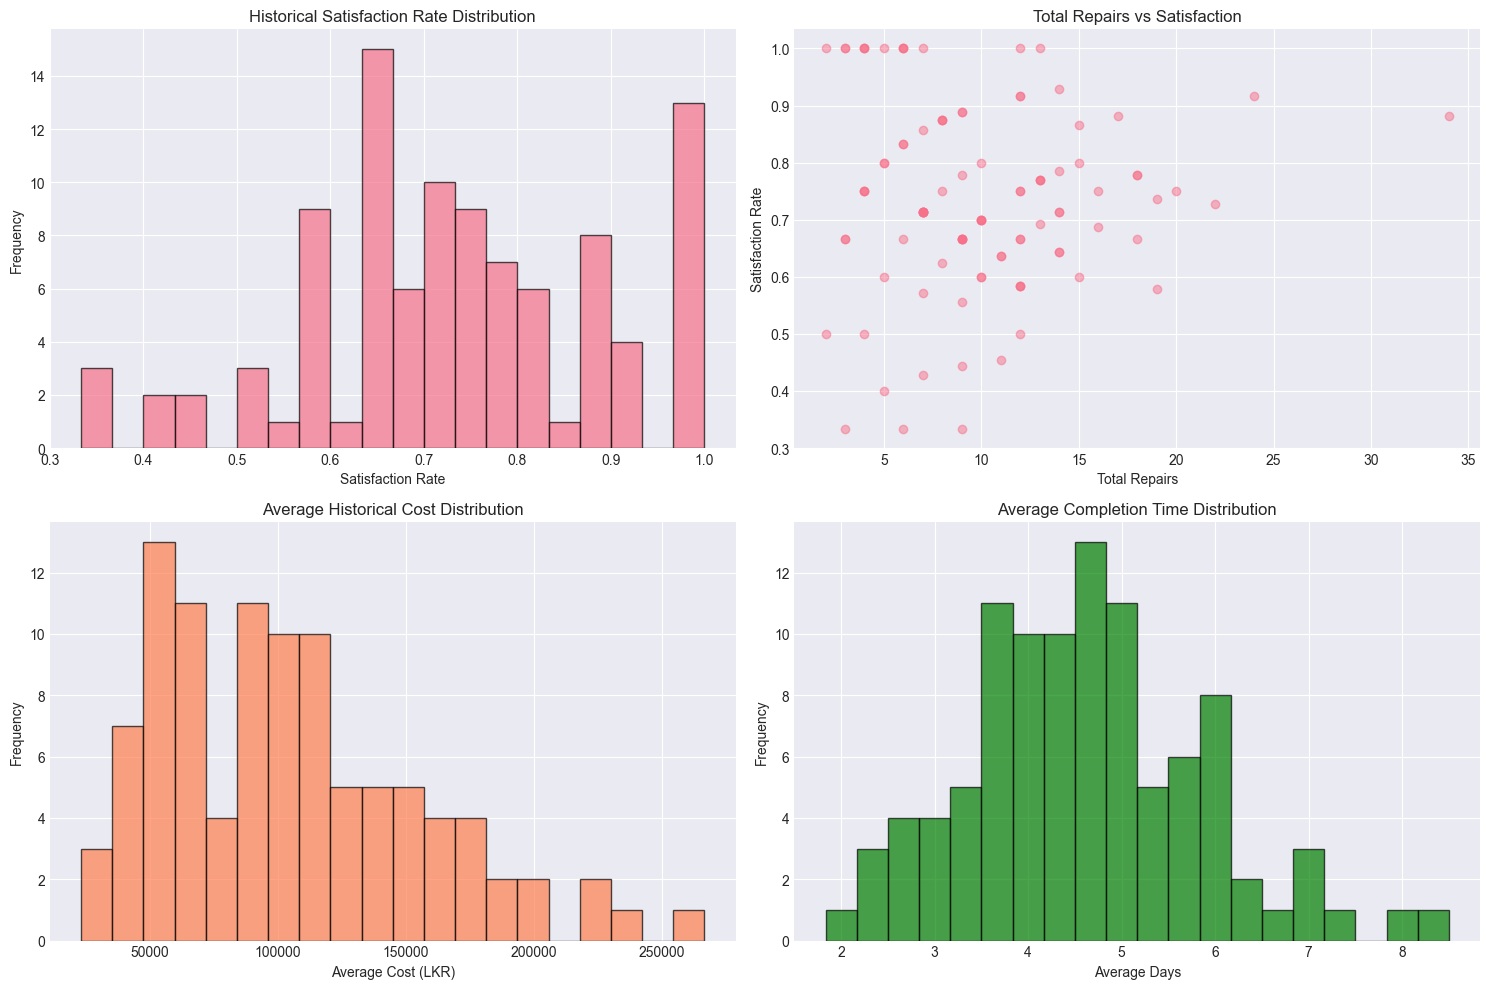

In [7]:
print("📊 Creating historical performance features...\n")

# Calculate garage-level aggregations from historical repairs
garage_performance = repairs_with_coords.groupby('garage_id').agg({
    'user_satisfied': ['mean', 'sum', 'count'],  # Satisfaction metrics
    'final_cost': ['mean', 'median', 'std'],      # Cost metrics
    'completion_days': ['mean', 'median', 'std'], # Time metrics
}).reset_index()

# Flatten column names
garage_performance.columns = ['_'.join(col).strip('_') for col in garage_performance.columns.values]
garage_performance = garage_performance.rename(columns={'garage_id_': 'garage_id'})

# Rename for clarity
garage_performance = garage_performance.rename(columns={
    'user_satisfied_mean': 'historical_satisfaction_rate',
    'user_satisfied_sum': 'total_satisfied_customers',
    'user_satisfied_count': 'total_repairs',
    'final_cost_mean': 'avg_historical_cost',
    'final_cost_median': 'median_historical_cost',
    'final_cost_std': 'cost_variability',
    'completion_days_mean': 'avg_completion_time',
    'completion_days_median': 'median_completion_time',
    'completion_days_std': 'time_variability'
})

# Fill NaN std values with 0
garage_performance['cost_variability'] = garage_performance['cost_variability'].fillna(0)
garage_performance['time_variability'] = garage_performance['time_variability'].fillna(0)

# Create reliability score (inverse of variability)
garage_performance['cost_reliability'] = 1 / (1 + garage_performance['cost_variability'] / 10000)
garage_performance['time_reliability'] = 1 / (1 + garage_performance['time_variability'])

print("✅ Historical performance features created!")
print(f"\n📊 Performance Summary:")
print(garage_performance[[
    'garage_id', 
    'historical_satisfaction_rate', 
    'total_repairs',
    'avg_historical_cost',
    'avg_completion_time'
]].head(10))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(garage_performance['historical_satisfaction_rate'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Historical Satisfaction Rate Distribution')
axes[0, 0].set_xlabel('Satisfaction Rate')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].scatter(garage_performance['total_repairs'], 
                   garage_performance['historical_satisfaction_rate'], alpha=0.5)
axes[0, 1].set_title('Total Repairs vs Satisfaction')
axes[0, 1].set_xlabel('Total Repairs')
axes[0, 1].set_ylabel('Satisfaction Rate')

axes[1, 0].hist(garage_performance['avg_historical_cost'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_title('Average Historical Cost Distribution')
axes[1, 0].set_xlabel('Average Cost (LKR)')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(garage_performance['avg_completion_time'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('Average Completion Time Distribution')
axes[1, 1].set_xlabel('Average Days')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
<a id='section5'></a>
## 5. User Preference Features

Create features based on user preferences and behavior

In [8]:
print("👤 Creating user preference features...\n")

# Merge user preferences if available
if 'user_id' in repairs_with_coords.columns and not users_df.empty:
    
    # Select relevant user features
    user_features = []
    if 'user_id' in users_df.columns:
        user_features.append('user_id')
    
    # Add preference columns if they exist
    pref_columns = [
        'preferred_price_range', 'max_acceptable_distance', 'min_acceptable_rating',
        'importance_speed', 'importance_cost', 'importance_quality', 'importance_proximity'
    ]
    
    for col in pref_columns:
        if col in users_df.columns:
            user_features.append(col)
    
    if len(user_features) > 1:
        repairs_with_coords = repairs_with_coords.merge(
            users_df[user_features],
            on='user_id',
            how='left'
        )
        
        print(f"✅ Merged {len(user_features)-1} user preference features")
        
        # Create preference alignment scores
        
        # 1. Distance preference alignment
        if 'max_acceptable_distance' in repairs_with_coords.columns and 'calculated_distance_km' in repairs_with_coords.columns:
            repairs_with_coords['distance_preference_match'] = (
                repairs_with_coords['calculated_distance_km'] <= 
                repairs_with_coords['max_acceptable_distance']
            ).astype(int)
            
            print("  ✓ Distance preference alignment created")
        
        # 2. Price range preference
        if 'preferred_price_range' in repairs_with_coords.columns:
            # Merge garage price range
            if 'price_range' not in repairs_with_coords.columns:
                repairs_with_coords = repairs_with_coords.merge(
                    garages_df[['garage_id', 'price_range']],
                    on='garage_id',
                    how='left',
                    suffixes=('', '_garage')
                )
            
            repairs_with_coords['price_preference_match'] = (
                repairs_with_coords['preferred_price_range'] == 
                repairs_with_coords['price_range']
            ).astype(int)
            
            print("  ✓ Price preference alignment created")
        
        # 3. Rating preference
        if 'min_acceptable_rating' in repairs_with_coords.columns:
            # Merge garage rating
            if 'avg_rating' not in repairs_with_coords.columns:
                repairs_with_coords = repairs_with_coords.merge(
                    garages_df[['garage_id', 'avg_rating']],
                    on='garage_id',
                    how='left',
                    suffixes=('', '_garage')
                )
            
            repairs_with_coords['rating_preference_match'] = (
                repairs_with_coords['avg_rating'] >= 
                repairs_with_coords['min_acceptable_rating']
            ).astype(int)
            
            print("  ✓ Rating preference alignment created")
        
        # 4. Overall preference alignment score
        preference_columns = [
            col for col in ['distance_preference_match', 'price_preference_match', 'rating_preference_match']
            if col in repairs_with_coords.columns
        ]
        
        if preference_columns:
            repairs_with_coords['overall_preference_score'] = repairs_with_coords[preference_columns].mean(axis=1)
            print(f"  ✓ Overall preference score created (based on {len(preference_columns)} factors)")
            
            print(f"\n📊 Preference Alignment Statistics:")
            for col in preference_columns:
                match_rate = repairs_with_coords[col].mean() * 100
                print(f"   {col}: {match_rate:.1f}% match rate")
        
    else:
        print("⚠️ No user preference columns found")
else:
    print("⚠️ User data not available or user_id not in repairs")

print("\n✅ User preference features completed!")

👤 Creating user preference features...

✅ Merged 7 user preference features
  ✓ Distance preference alignment created
  ✓ Price preference alignment created
  ✓ Rating preference alignment created
  ✓ Overall preference score created (based on 3 factors)

📊 Preference Alignment Statistics:
   distance_preference_match: 33.2% match rate
   price_preference_match: 40.7% match rate
   rating_preference_match: 68.8% match rate

✅ User preference features completed!


---
<a id='section6'></a>
## 6. Availability & Capacity Features

Create features related to garage capacity and availability

🏭 Creating availability and capacity features...

✅ Capacity features created!

📊 Availability Statistics:
   Mean utilization: 47.6%
   Mean availability score: 52.4%

📊 Availability Status Distribution:
availability_status
high        50
moderate    24
low         11
Name: count, dtype: int64


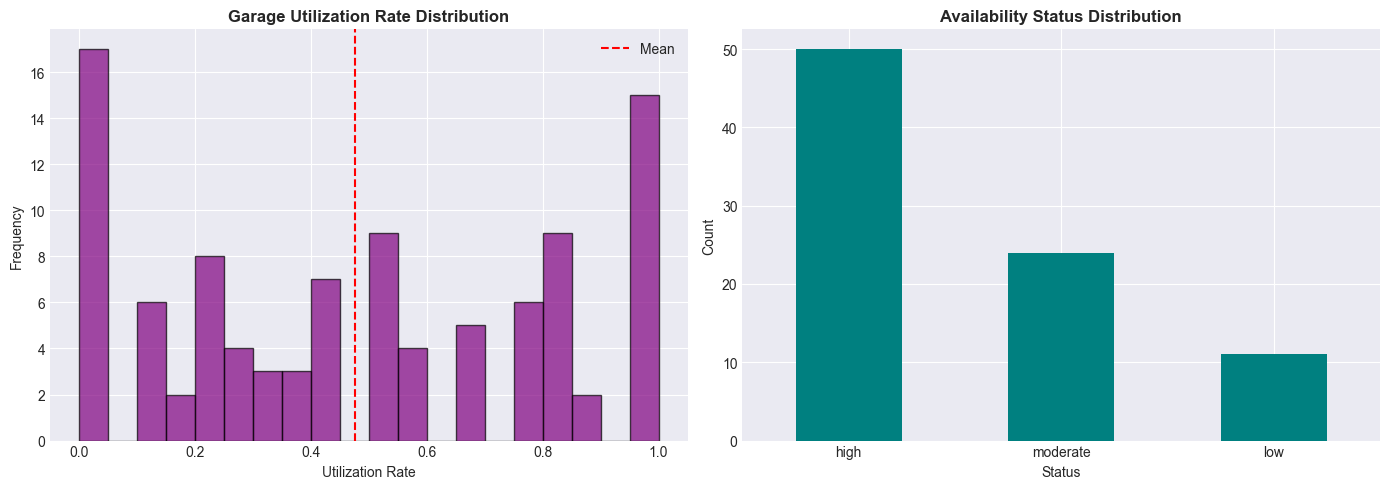


📅 Analyzing time-based capacity patterns...
  ✓ Time-based utilization patterns added

✅ Availability features completed!


In [9]:
print("🏭 Creating availability and capacity features...\n")

# Calculate capacity metrics from garages dataset
if 'available_bays' in garages_df.columns and 'total_bays' in garages_df.columns:
    
    garages_capacity = garages_df[['garage_id', 'total_bays', 'available_bays']].copy()
    
    # Calculate utilization rate
    garages_capacity['current_utilization'] = (
        (garages_capacity['total_bays'] - garages_capacity['available_bays']) / 
        garages_capacity['total_bays']
    )
    
    # Availability score (higher is better)
    garages_capacity['availability_score'] = (
        garages_capacity['available_bays'] / garages_capacity['total_bays']
    )
    
    # Categorize availability
    garages_capacity['availability_status'] = pd.cut(
        garages_capacity['availability_score'],
        bins=[0, 0.2, 0.5, 1.0],
        labels=['low', 'moderate', 'high']
    )
    
    # Merge with repairs data
    repairs_with_coords = repairs_with_coords.merge(
        garages_capacity[['garage_id', 'current_utilization', 'availability_score', 'availability_status']],
        on='garage_id',
        how='left'
    )
    
    print("✅ Capacity features created!")
    print(f"\n📊 Availability Statistics:")
    print(f"   Mean utilization: {garages_capacity['current_utilization'].mean():.1%}")
    print(f"   Mean availability score: {garages_capacity['availability_score'].mean():.1%}")
    print(f"\n📊 Availability Status Distribution:")
    print(garages_capacity['availability_status'].value_counts())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(garages_capacity['current_utilization'], bins=20, edgecolor='black', alpha=0.7, color='purple')
    axes[0].set_title('Garage Utilization Rate Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Utilization Rate')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(garages_capacity['current_utilization'].mean(), color='red', linestyle='--', label='Mean')
    axes[0].legend()
    
    garages_capacity['availability_status'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
    axes[1].set_title('Availability Status Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Status')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ Capacity columns not found in garages dataset")

# If capacity timeline data is available, calculate time-based patterns
if not capacity_df.empty and 'garage_id' in capacity_df.columns:
    print("\n📅 Analyzing time-based capacity patterns...")
    
    # Calculate average utilization by garage from timeline
    if 'utilization_rate' in capacity_df.columns:
        avg_utilization = capacity_df.groupby('garage_id')['utilization_rate'].agg([
            ('avg_utilization', 'mean'),
            ('utilization_std', 'std'),
            ('max_utilization', 'max'),
            ('min_utilization', 'min')
        ]).reset_index()
        
        # Merge with repairs
        repairs_with_coords = repairs_with_coords.merge(
            avg_utilization,
            on='garage_id',
            how='left'
        )
        
        print("  ✓ Time-based utilization patterns added")

print("\n✅ Availability features completed!")

---
<a id='section7'></a>
## 7. Price & Cost Features

Create features related to pricing and cost competitiveness

💰 Creating price and cost features...

✅ Pricing features created!

📊 Pricing Statistics:
   Median hourly rate: 3443.50 LKR
   Mean hourly rate: 3348.72 LKR

📊 Relative Price Category:
relative_price_category
market_rate     51
below_market    29
above_market    20
Name: count, dtype: int64

  ✓ Cost expectation features created

📊 Cost Overrun Statistics:
   Mean overrun: 527.74 LKR
   Mean overrun %: 3.1%
   Mean cost accuracy: 0.845


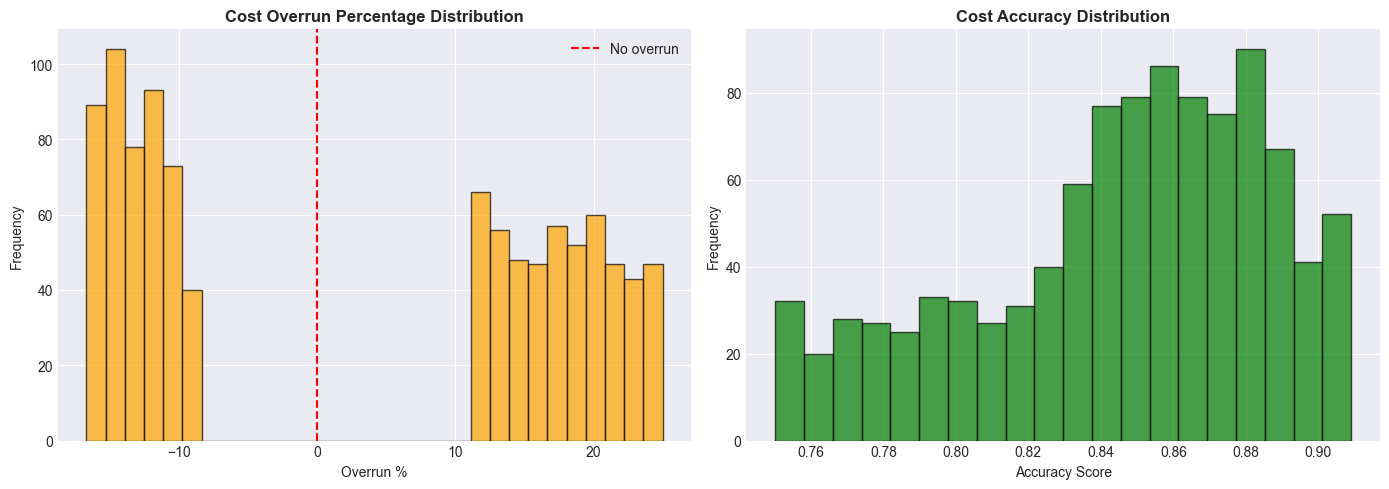


✅ Price and cost features completed!


In [10]:
print("💰 Creating price and cost features...\n")

# Merge garage pricing information
if 'avg_hourly_rate' in garages_df.columns:
    garage_pricing = garages_df[['garage_id', 'avg_hourly_rate']].copy()
    
    # Calculate price competitiveness (lower is more competitive)
    median_rate = garage_pricing['avg_hourly_rate'].median()
    garage_pricing['price_competitiveness'] = median_rate / garage_pricing['avg_hourly_rate']
    
    # Price category relative to market
    garage_pricing['relative_price_category'] = pd.cut(
        garage_pricing['avg_hourly_rate'],
        bins=[0, median_rate * 0.8, median_rate * 1.2, float('inf')],
        labels=['below_market', 'market_rate', 'above_market']
    )
    
    # Merge with repairs
    repairs_with_coords = repairs_with_coords.merge(
        garage_pricing,
        on='garage_id',
        how='left',
        suffixes=('', '_pricing')
    )
    
    print("✅ Pricing features created!")
    print(f"\n📊 Pricing Statistics:")
    print(f"   Median hourly rate: {median_rate:.2f} LKR")
    print(f"   Mean hourly rate: {garage_pricing['avg_hourly_rate'].mean():.2f} LKR")
    print(f"\n📊 Relative Price Category:")
    print(garage_pricing['relative_price_category'].value_counts())

# Cost vs expectation features
if 'final_cost' in repairs_with_coords.columns and 'estimated_cost' in repairs_with_coords.columns:
    # Cost overrun
    repairs_with_coords['cost_overrun'] = (
        repairs_with_coords['final_cost'] - repairs_with_coords['estimated_cost']
    )
    
    # Cost overrun percentage
    repairs_with_coords['cost_overrun_pct'] = (
        repairs_with_coords['cost_overrun'] / repairs_with_coords['estimated_cost']
    ) * 100
    
    # Cost accuracy (1 = perfect, lower = less accurate)
    repairs_with_coords['cost_accuracy'] = 1 - abs(repairs_with_coords['cost_overrun_pct']) / 100
    repairs_with_coords['cost_accuracy'] = repairs_with_coords['cost_accuracy'].clip(lower=0)
    
    print("\n  ✓ Cost expectation features created")
    print(f"\n📊 Cost Overrun Statistics:")
    print(f"   Mean overrun: {repairs_with_coords['cost_overrun'].mean():.2f} LKR")
    print(f"   Mean overrun %: {repairs_with_coords['cost_overrun_pct'].mean():.1f}%")
    print(f"   Mean cost accuracy: {repairs_with_coords['cost_accuracy'].mean():.3f}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(repairs_with_coords['cost_overrun_pct'].clip(-50, 50), 
                 bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[0].set_title('Cost Overrun Percentage Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Overrun %')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(0, color='red', linestyle='--', label='No overrun')
    axes[0].legend()
    
    axes[1].hist(repairs_with_coords['cost_accuracy'], bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[1].set_title('Cost Accuracy Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Accuracy Score')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

print("\n✅ Price and cost features completed!")

---
<a id='section8'></a>
## 8. Create Training Dataset

Combine all features and prepare final training dataset

In [11]:
print("🎯 Creating final training dataset...\n")

# Select final feature columns
feature_columns = []

# Core identifiers
id_columns = ['repair_id', 'garage_id', 'user_id']
for col in id_columns:
    if col in repairs_with_coords.columns:
        feature_columns.append(col)

# Distance features
distance_features = [
    'calculated_distance_km', 'distance_score', 'is_nearby', 'is_very_close'
]
for col in distance_features:
    if col in repairs_with_coords.columns:
        feature_columns.append(col)

# Specialization features
spec_features = ['specialization_match_score']
for col in spec_features:
    if col in repairs_with_coords.columns:
        feature_columns.append(col)

# Historical performance (merge from garage_performance)
if 'garage_id' in repairs_with_coords.columns:
    repairs_with_coords = repairs_with_coords.merge(
        garage_performance,
        on='garage_id',
        how='left',
        suffixes=('', '_hist')
    )
    
    hist_features = [
        'historical_satisfaction_rate', 'total_repairs', 'avg_historical_cost',
        'avg_completion_time', 'cost_reliability', 'time_reliability'
    ]
    for col in hist_features:
        if col in repairs_with_coords.columns:
            feature_columns.append(col)

# User preference features
pref_features = [
    'overall_preference_score', 'distance_preference_match', 
    'price_preference_match', 'rating_preference_match'
]
for col in pref_features:
    if col in repairs_with_coords.columns:
        feature_columns.append(col)

# Availability features
avail_features = ['availability_score', 'current_utilization']
for col in avail_features:
    if col in repairs_with_coords.columns:
        feature_columns.append(col)

# Price features
price_features = [
    'avg_hourly_rate', 'price_competitiveness', 'cost_accuracy'
]
for col in price_features:
    if col in repairs_with_coords.columns:
        feature_columns.append(col)

# Garage quality features (from original garages dataset)
quality_features = ['avg_rating', 'num_reviews', 'years_in_business', 'certified']
for col in quality_features:
    if col not in repairs_with_coords.columns:
        if col in garages_df.columns:
            repairs_with_coords = repairs_with_coords.merge(
                garages_df[['garage_id', col]],
                on='garage_id',
                how='left',
                suffixes=('', '_new')
            )
    if col in repairs_with_coords.columns:
        feature_columns.append(col)

# Target variable
target_column = 'user_satisfied'
if target_column in repairs_with_coords.columns:
    feature_columns.append(target_column)

# Additional outcome columns
outcome_columns = ['satisfaction_score', 'would_recommend', 'final_cost', 'completion_days']
for col in outcome_columns:
    if col in repairs_with_coords.columns and col not in feature_columns:
        feature_columns.append(col)

# Create final dataset
training_data = repairs_with_coords[feature_columns].copy()

# Remove duplicates from column names (if any)
feature_columns = list(dict.fromkeys(feature_columns))

print(f"✅ Training dataset created!")
print(f"\n📊 Dataset Shape: {training_data.shape}")
print(f"\n📋 Features included ({len(feature_columns)} total):")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i:2d}. {col}")

# Check for missing values
missing_summary = training_data.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print(f"\n⚠️ Missing values found:")
    print(missing_summary)
    print("\nFilling missing values...")
    
    # Fill missing values
    for col in training_data.columns:
        if training_data[col].isnull().sum() > 0:
            if training_data[col].dtype in ['float64', 'int64']:
                training_data[col].fillna(training_data[col].median(), inplace=True)
            else:
                training_data[col].fillna(training_data[col].mode()[0], inplace=True)
    
    print("✓ Missing values filled")
else:
    print("\n✅ No missing values!")

# Display sample
print("\n📊 Sample of training data:")
display(training_data.head(10))

🎯 Creating final training dataset...

✅ Training dataset created!

📊 Dataset Shape: (1000, 32)

📋 Features included (32 total):
    1. repair_id
    2. garage_id
    3. user_id
    4. calculated_distance_km
    5. distance_score
    6. is_nearby
    7. is_very_close
    8. specialization_match_score
    9. historical_satisfaction_rate
   10. total_repairs
   11. avg_historical_cost
   12. avg_completion_time
   13. cost_reliability
   14. time_reliability
   15. overall_preference_score
   16. distance_preference_match
   17. price_preference_match
   18. rating_preference_match
   19. availability_score
   20. current_utilization
   21. avg_hourly_rate
   22. price_competitiveness
   23. cost_accuracy
   24. avg_rating
   25. num_reviews
   26. years_in_business
   27. certified
   28. user_satisfied
   29. satisfaction_score
   30. would_recommend
   31. final_cost
   32. completion_days

✅ No missing values!

📊 Sample of training data:


,repair_id,garage_id,user_id,calculated_distance_km,distance_score,is_nearby,is_very_close,specialization_match_score,historical_satisfaction_rate,total_repairs,avg_historical_cost,avg_completion_time,cost_reliability,time_reliability,overall_preference_score,distance_preference_match,price_preference_match,rating_preference_match,availability_score,current_utilization,avg_hourly_rate,price_competitiveness,cost_accuracy,avg_rating,num_reviews,years_in_business,certified,user_satisfied,satisfaction_score,would_recommend,final_cost,completion_days
0,REP0001,GAR035,USER027,18.345,0.052,0,0,0.800,0.625,8,23076.125,2.625,0.441,0.385,0.333,0,1,0,1.000,0.000,2506,1.374,0.758,3.640,15,1,0,1,0.516,0,20122,1
1,REP0002,GAR081,USER224,11.253,0.082,0,0,0.300,0.500,4,101927.000,6.000,0.094,0.149,0.333,0,1,0,0.000,1.000,2697,1.277,0.862,3.880,26,30,1,1,0.657,1,64837,3
2,REP0003,GAR027,USER176,15.634,0.060,0,0,1.000,0.750,16,122500.125,4.625,0.068,0.197,0.333,0,0,1,0.800,0.200,2904,1.186,0.860,4.450,153,4,1,1,0.815,1,75239,6
3,REP0004,GAR041,USER249,3.575,0.219,1,0,0.800,0.769,13,108443.923,5.462,0.095,0.236,0.667,1,0,1,1.000,0.000,3752,0.918,0.858,3.860,15,14,1,1,0.542,0,98844,4
4,REP0005,GAR019,USER294,5.949,0.144,0,0,0.300,0.867,15,194796.667,6.133,0.053,0.175,0.333,0,1,0,0.714,0.286,3800,0.906,0.828,4.100,50,7,1,1,0.585,0,97965,3
5,REP0006,GAR033,USER091,17.370,0.054,0,0,0.300,0.455,11,160421.818,5.455,0.056,0.194,0.667,0,1,1,0.000,1.000,4904,0.702,0.803,3.910,45,22,0,0,0.498,0,30318,2
6,REP0007,GAR006,USER046,12.309,0.075,0,0,0.800,0.636,11,228740.727,6.091,0.045,0.164,0.333,0,1,0,0.143,0.857,4792,0.719,0.883,4.200,15,8,0,1,0.759,1,28350,1
7,REP0008,GAR091,USER084,18.683,0.051,0,0,0.300,0.889,9,190512.333,5.000,0.057,0.217,0.667,1,0,1,1.000,0.000,5118,0.673,0.860,4.060,34,3,1,1,0.620,0,459058,12
8,REP0009,GAR050,USER086,17.251,0.055,0,0,0.800,0.700,10,176583.300,8.500,0.075,0.145,0.333,0,0,1,0.875,0.125,3950,0.872,0.853,4.030,50,16,1,0,0.446,0,318939,15
9,REP0010,GAR029,USER071,12.170,0.076,0,0,0.300,0.600,10,98671.500,3.600,0.089,0.192,0.667,1,1,0,0.250,0.750,4266,0.807,0.893,3.880,22,10,0,1,0.576,0,31261,1


---
<a id='section9'></a>
## 9. Feature Analysis

Analyze feature distributions and correlations

FEATURE ANALYSIS

📊 Analyzing 29 numeric features...

Statistical Summary:


,calculated_distance_km,distance_score,is_nearby,is_very_close,specialization_match_score,historical_satisfaction_rate,total_repairs,avg_historical_cost,avg_completion_time,cost_reliability,time_reliability,overall_preference_score,distance_preference_match,price_preference_match,rating_preference_match,availability_score,current_utilization,avg_hourly_rate,price_competitiveness,cost_accuracy,avg_rating,num_reviews,years_in_business,certified,user_satisfied,satisfaction_score,would_recommend,final_cost,completion_days
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,13.254,0.085,0.066,0.012,0.632,0.737,12.746,106866.654,4.675,0.118,0.255,0.476,0.332,0.407,0.688,0.530,0.470,3356.768,1.118,0.845,4.067,60.847,16.694,0.604,0.737,0.639,0.451,106866.654,4.675
std,4.718,0.055,0.248,0.109,0.301,0.144,6.192,48810.331,1.178,0.080,0.067,0.267,0.471,0.492,0.464,0.339,0.339,923.507,0.353,0.041,0.216,65.365,9.488,0.489,0.440,0.083,0.498,119522.030,3.400
min,0.881,0.048,0.000,0.000,0.300,0.333,2.000,23076.125,1.833,0.045,0.128,0.000,0.000,0.000,0.000,0.000,0.000,1500.000,0.603,0.750,3.640,15.000,1.000,0.000,0.000,0.374,0.000,10242.000,1.000
25%,9.960,0.055,0.000,0.000,0.300,0.667,9.000,67898.750,3.889,0.065,0.200,0.333,0.000,0.000,0.000,0.200,0.200,2506.000,0.869,0.820,3.900,19.000,8.000,0.000,0.000,0.584,0.000,28232.250,2.000
50%,13.913,0.067,0.000,0.000,0.800,0.727,12.000,98671.500,4.625,0.086,0.240,0.333,0.000,0.000,1.000,0.600,0.400,3536.000,0.974,0.852,4.060,37.000,18.000,1.000,1.000,0.638,0.000,65867.500,3.000
75%,17.162,0.091,0.000,0.000,1.000,0.857,15.000,139390.533,5.455,0.127,0.305,0.667,1.000,1.000,1.000,0.800,0.800,3963.000,1.374,0.877,4.200,72.000,26.000,1.000,1.000,0.695,1.000,103632.750,6.000
max,20.035,0.532,1.000,1.000,1.000,1.000,34.000,266487.500,8.500,0.444,0.429,1.000,1.000,1.000,1.000,1.000,1.000,5714.000,2.296,0.909,4.660,481.000,30.000,1.000,1.000,0.864,1.000,496638.000,15.000



🎯 Correlation with Target (user_satisfied):
user_satisfied                  1.000
historical_satisfaction_rate    0.326
satisfaction_score              0.309
would_recommend                 0.126
avg_rating                      0.121
num_reviews                     0.098
specialization_match_score      0.074
cost_accuracy                   0.060
total_repairs                   0.058
avg_historical_cost             0.049
overall_preference_score        0.043
price_preference_match          0.037
avg_hourly_rate                 0.037
availability_score              0.026
rating_preference_match         0.024
distance_preference_match       0.011
years_in_business               0.011
certified                       0.009
calculated_distance_km          0.002
avg_completion_time            -0.001
is_very_close                  -0.018
current_utilization            -0.026
time_reliability               -0.028
cost_reliability               -0.033
distance_score                 -0.036
final

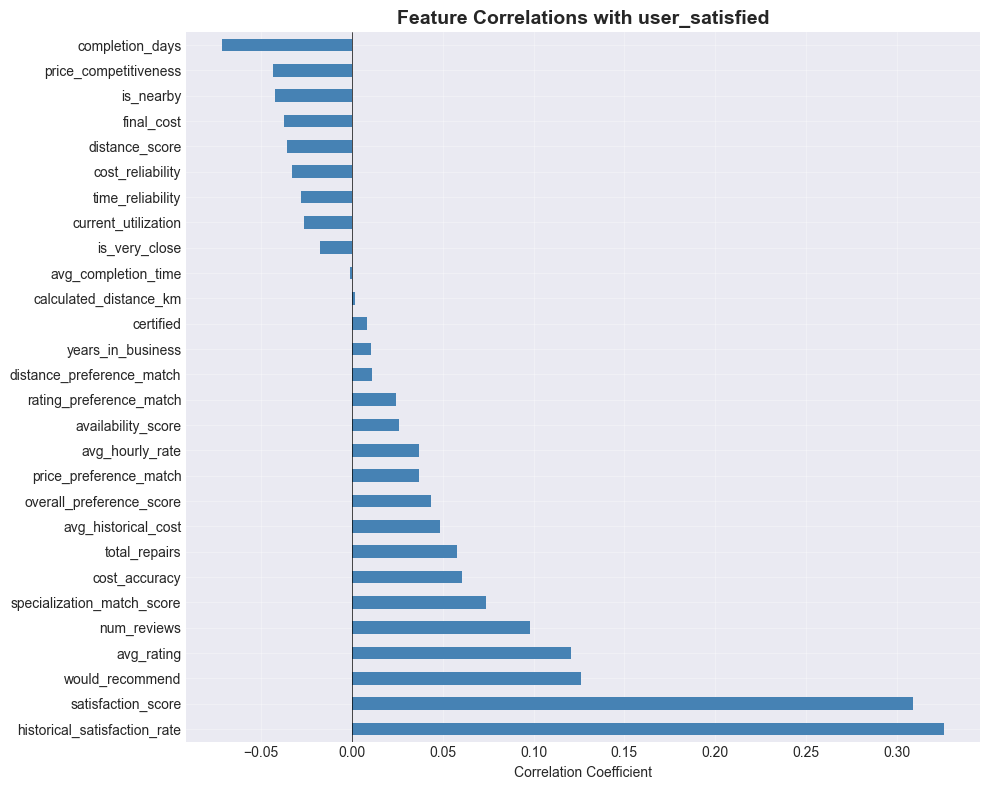


📊 Feature Correlation Heatmap:


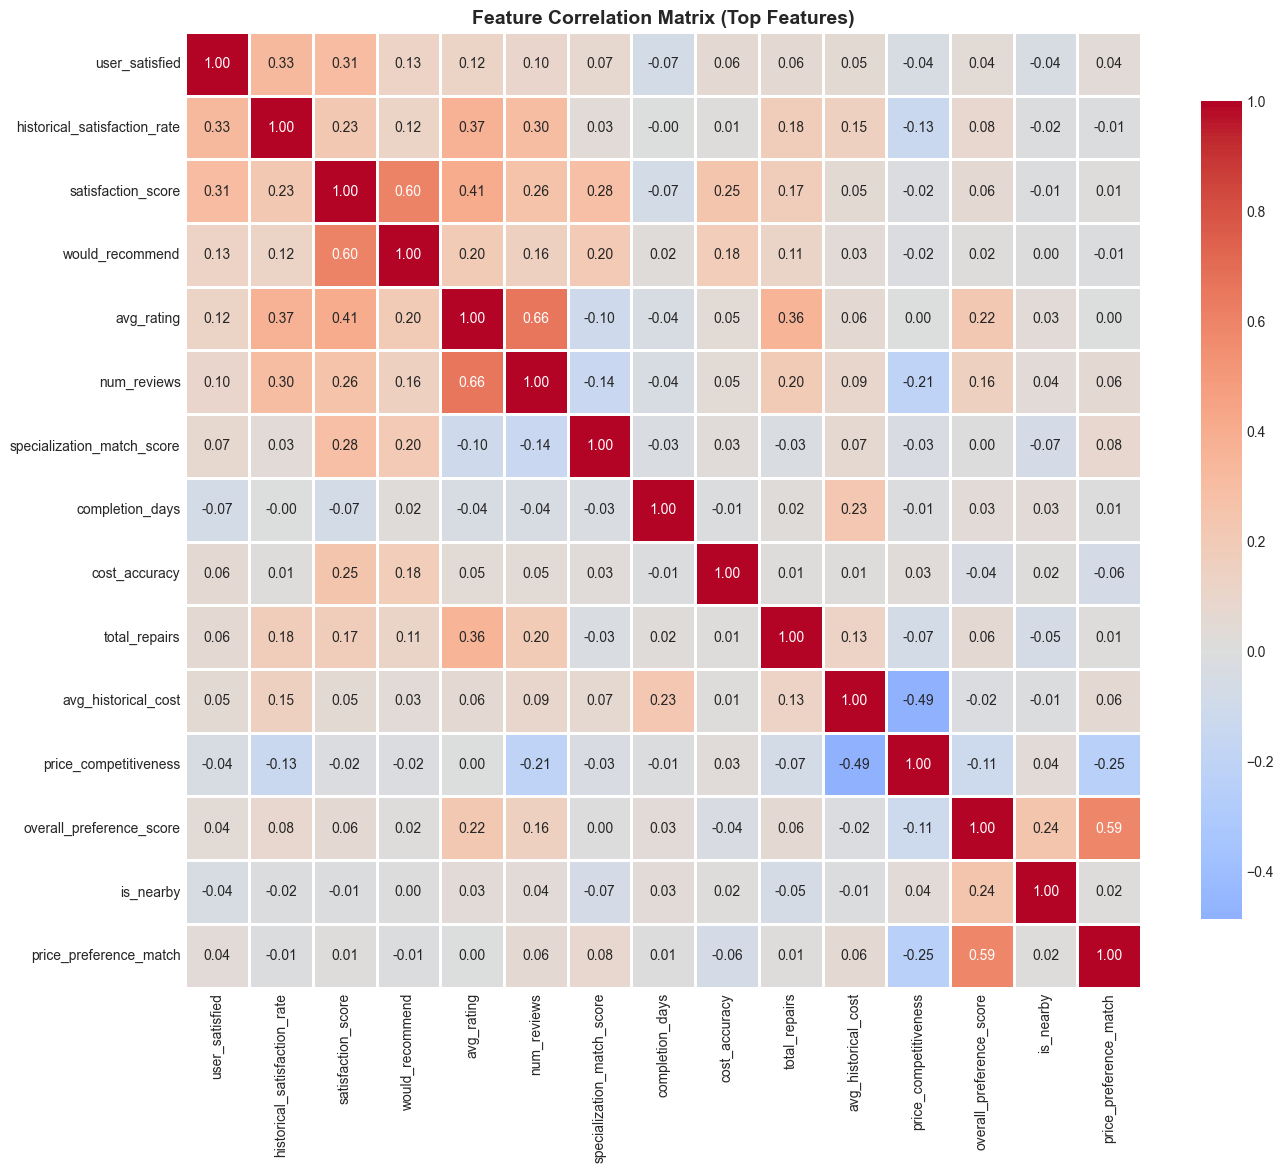

In [12]:
print("="*80)
print("FEATURE ANALYSIS")
print("="*80)

# Select only numeric features for analysis
numeric_features = training_data.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns
numeric_features = [col for col in numeric_features if 'id' not in col.lower()]

print(f"\n📊 Analyzing {len(numeric_features)} numeric features...\n")

# Statistical summary
print("Statistical Summary:")
display(training_data[numeric_features].describe())

# Correlation with target
if target_column in training_data.columns:
    print(f"\n🎯 Correlation with Target ({target_column}):")
    correlations = training_data[numeric_features].corr()[target_column].sort_values(ascending=False)
    print(correlations)
    
    # Visualize top correlations
    plt.figure(figsize=(10, 8))
    correlations.drop(target_column).plot(kind='barh', color='steelblue')
    plt.title(f'Feature Correlations with {target_column}', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Feature correlation heatmap
print("\n📊 Feature Correlation Heatmap:")

# Select top features for clearer visualization
if len(numeric_features) > 15:
    # Get top correlated features with target
    if target_column in training_data.columns:
        top_features = abs(correlations).sort_values(ascending=False).head(15).index.tolist()
    else:
        top_features = numeric_features[:15]
else:
    top_features = numeric_features

plt.figure(figsize=(14, 12))
corr_matrix = training_data[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (Top Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 Key Feature Distributions:


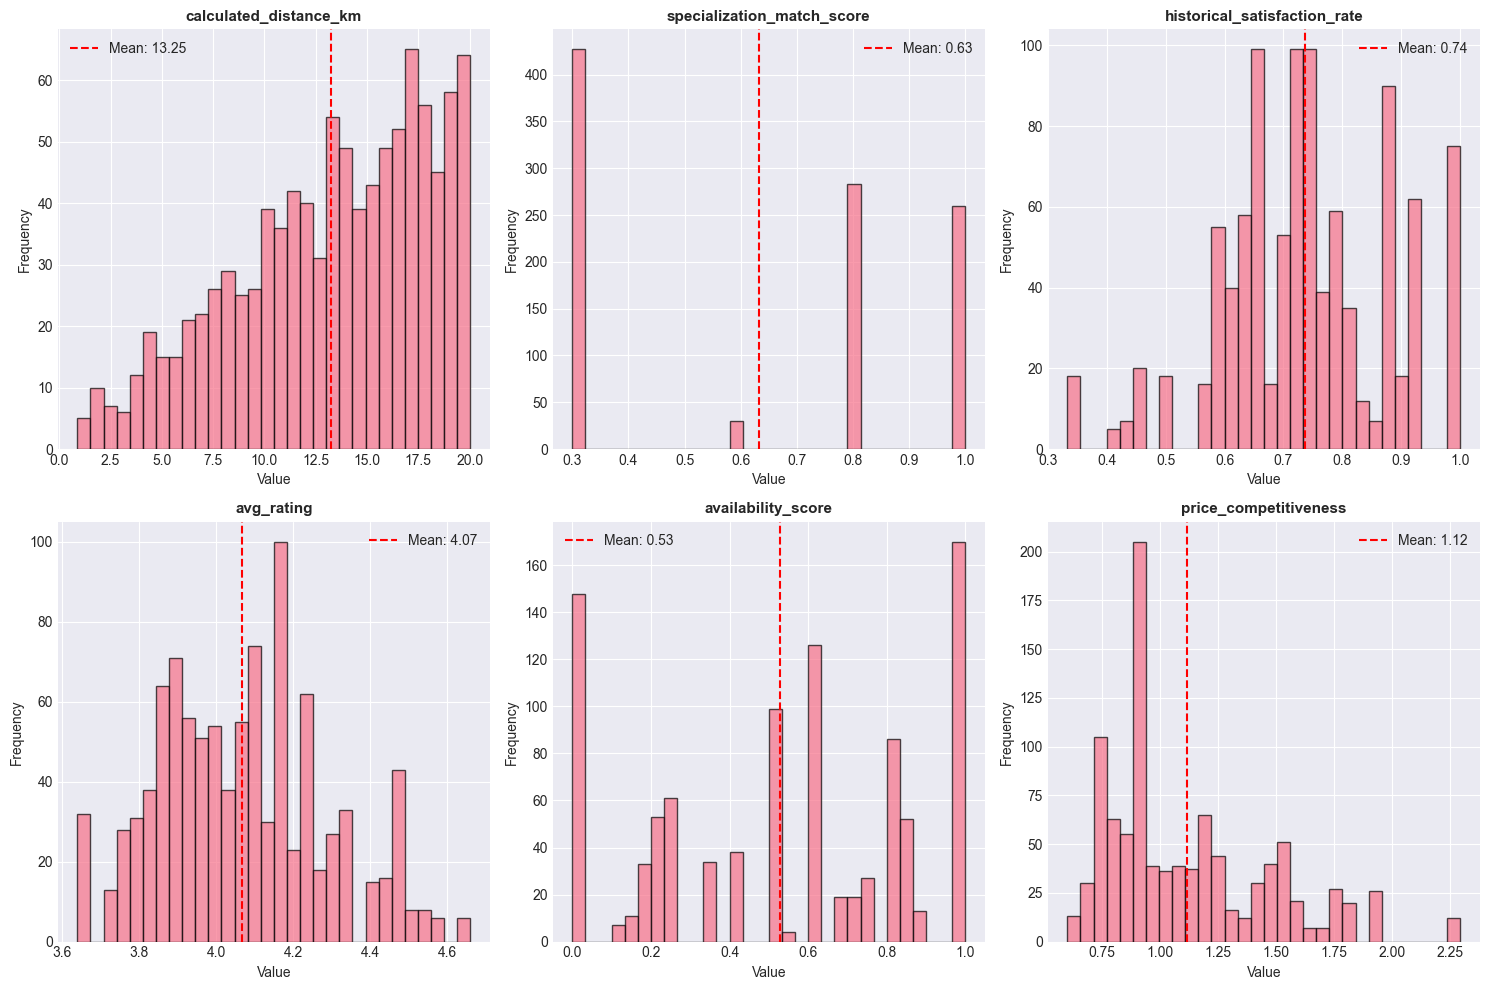


✅ Feature analysis completed!


In [13]:
# Distribution of key features
print("\n📊 Key Feature Distributions:")

key_features = [
    'calculated_distance_km', 'specialization_match_score', 'historical_satisfaction_rate',
    'avg_rating', 'availability_score', 'price_competitiveness'
]

# Filter to existing features
key_features = [f for f in key_features if f in training_data.columns]

if len(key_features) > 0:
    n_features = len(key_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for i, feature in enumerate(key_features):
        axes[i].hist(training_data[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].axvline(training_data[feature].mean(), color='red', linestyle='--', 
                       label=f'Mean: {training_data[feature].mean():.2f}')
        axes[i].legend()
    
    # Hide empty subplots
    for i in range(len(key_features), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("\n✅ Feature analysis completed!")

---
<a id='section10'></a>
## 10. Save Engineered Features

In [17]:
# Create output directory
import os
output_dir = 'data/processed/'
os.makedirs(output_dir, exist_ok=True)

print("💾 Saving engineered features...\n")

# Save main training dataset
training_data.to_csv(output_dir + 'training_features.csv', index=False)
print(f"✓ Saved: training_features.csv ({training_data.shape})")

# Save garage performance aggregations
garage_performance.to_csv(output_dir + 'garage_performance_features.csv', index=False)
print(f"✓ Saved: garage_performance_features.csv ({garage_performance.shape})")

# Save feature list
feature_list = pd.DataFrame({
    'feature_name': feature_columns,
    'feature_type': [training_data[col].dtype for col in feature_columns]
})
feature_list.to_csv(output_dir + 'feature_list.csv', index=False)
print(f"✓ Saved: feature_list.csv ({len(feature_columns)} features)")

# Save summary statistics
summary_stats = training_data[numeric_features].describe()
summary_stats.to_csv(output_dir + 'feature_statistics.csv')
print(f"✓ Saved: feature_statistics.csv")

# Save correlation matrix
if target_column in training_data.columns:
    correlations_df = pd.DataFrame({
        'feature': correlations.index,
        'correlation': correlations.values
    })
    correlations_df.to_csv(output_dir + 'target_correlations.csv', index=False)
    print(f"✓ Saved: target_correlations.csv")

print(f"\n✅ All engineered features saved successfully!")
print(f"📁 Location: {output_dir}")

# Print summary
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"\n✅ Total Features Created: {len(feature_columns)}")
print(f"✅ Training Records: {len(training_data):,}")
print(f"✅ Target Variable: {target_column}")
print(f"✅ Missing Values: {training_data.isnull().sum().sum()}")
print("\n📊 Feature Categories:")
print(f"   • Distance-based: {len([f for f in feature_columns if 'distance' in f.lower()])}")
print(f"   • Specialization: {len([f for f in feature_columns if 'specialization' in f.lower() or 'match' in f.lower()])}")
print(f"   • Historical: {len([f for f in feature_columns if 'historical' in f.lower() or 'avg_' in f.lower()])}")
print(f"   • Preference: {len([f for f in feature_columns if 'preference' in f.lower()])}")
print(f"   • Availability: {len([f for f in feature_columns if 'availability' in f.lower() or 'utilization' in f.lower()])}")
print(f"   • Price/Cost: {len([f for f in feature_columns if 'price' in f.lower() or 'cost' in f.lower()])}")
print("\n" + "="*80)

💾 Saving engineered features...

✓ Saved: training_features.csv ((1000, 32))
✓ Saved: garage_performance_features.csv ((100, 12))
✓ Saved: feature_list.csv (32 features)
✓ Saved: feature_statistics.csv
✓ Saved: target_correlations.csv

✅ All engineered features saved successfully!
📁 Location: data/processed/

FEATURE ENGINEERING SUMMARY

✅ Total Features Created: 32
✅ Training Records: 1,000
✅ Target Variable: user_satisfied
✅ Missing Values: 0

📊 Feature Categories:
   • Distance-based: 3
   • Specialization: 4
   • Historical: 5
   • Preference: 4
   • Availability: 2
   • Price/Cost: 6



---
## Summary & Next Steps

### ✅ Completed in This Notebook:
1. ✓ Created distance-based features using Haversine formula
2. ✓ Built specialization matching scores
3. ✓ Aggregated historical performance metrics
4. ✓ Created user preference alignment features
5. ✓ Added availability and capacity features
6. ✓ Engineered price competitiveness features
7. ✓ Combined all features into training dataset
8. ✓ Analyzed feature distributions and correlations
9. ✓ Saved all engineered features

### 📊 Key Features Created:
- **Distance Features:** Haversine distance, distance score, proximity indicators
- **Match Features:** Specialization alignment, repair type matching
- **Quality Features:** Historical satisfaction, reliability scores
- **Preference Features:** User preference alignments
- **Operational Features:** Availability scores, utilization rates
- **Cost Features:** Price competitiveness, cost accuracy

### 🎯 Next Steps:
**Notebook 3: Model Training & Evaluation**
- Split data into train/validation/test sets
- Train multiple ML models (Gradient Boosting, XGBoost, Random Forest)
- Evaluate model performance
- Analyze feature importance
- Perform hyperparameter tuning
- Save best model for deployment

---

**End of Notebook 2**